In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [11]:
dataset1 = pd.read_csv('/content/DL data set1 - Sheet1 (1).csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values

In [12]:
print(X)
print(y)

[[ 3]
 [ 2]
 [ 6]
 [69]
 [54]
 [ 5]
 [33]
 [ 3]
 [ 7]
 [ 8]
 [10]
 [13]
 [ 2]
 [10]]
[[ 5]
 [12]
 [10]
 [15]
 [ 6]
 [ 4]
 [14]
 [ 7]
 [22]
 [19]
 [20]
 [41]
 [18]
 [55]]


In [14]:
dataset1.head()

,Input,Output
0,3,5
1,2,12
2,6,10
3,69,15
4,54,6


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [16]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [18]:
# Name:T Ajay
# Register Number:212223230007
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss':[]}

  def forward(self,x):
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    x=self.fc3(x)
    return x

In [19]:
# Initialize the Model, Loss Function, and Optimizer
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(ai_brain.parameters(), lr=0.001)#lr=learning rate

In [20]:
# Name:T Ajay
# Register Number:212223230007
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss=criterion(ai_brain(X_train),y_train)
        loss.backward()
        optimizer.step()


        ai_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [21]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 350.435394
Epoch [200/2000], Loss: 314.282990
Epoch [400/2000], Loss: 190.622482
Epoch [600/2000], Loss: 131.719238
Epoch [800/2000], Loss: 121.432022
Epoch [1000/2000], Loss: 116.742226
Epoch [1200/2000], Loss: 114.709991
Epoch [1400/2000], Loss: 113.981606
Epoch [1600/2000], Loss: 113.780571
Epoch [1800/2000], Loss: 113.739151


In [22]:
with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 334.683990


In [23]:
loss_df = pd.DataFrame(ai_brain.history)

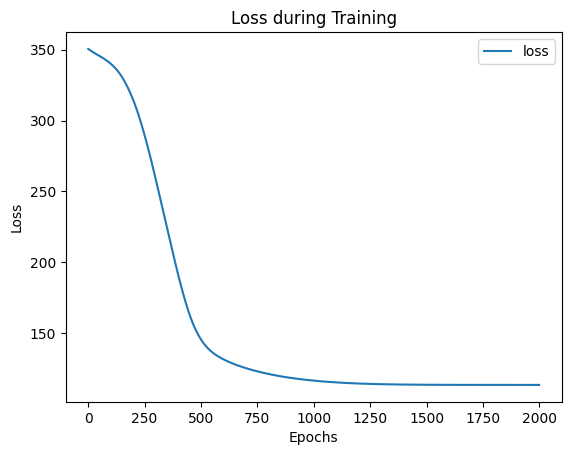

In [24]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [25]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 16.21142578125
